In [21]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage

In [22]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")


class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]


class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [23]:
model = ChatOllama(base_url="http://206.1.53.104:11434/", model="qwen2.5-coder:7b")

In [24]:
def orchestrator(state: State) -> State:

    plan = model.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=("Create a blog plan with 5-7 sections on the following topic.")
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [25]:
def fanout(state: State):
    return [
        Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
        for task in state["plan"].tasks
    ]

In [26]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = model.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [27]:
from pathlib import Path


def reducer(state: State) -> dict:

    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [28]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

In [29]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

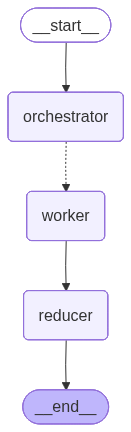

In [30]:
app = g.compile()

app

In [31]:
app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Exploring Self-Attention Mechanism: A Comprehensive Guide', tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Provide an overview of the self-attention mechanism and its importance in modern machine learning and artificial intelligence.'), Task(id=2, title='The Mathematics Behind Self-Attention', brief='Explain the mathematical concepts behind self-attention and how it compares to traditional attention mechanisms.'), Task(id=3, title='Applications of Self-Attention in Natural Language Processing', brief='Discuss the use of self-attention in various NLP tasks such as machine translation, sentiment analysis, and text summarization.'), Task(id=4, title='Self-Attention in Computer Vision', brief='Explore how self-attention can be applied to computer vision tasks like image recognition and object detection.'), Task(id=5, title='Challenges and Limitations of Self-Attention', brief='Discuss the current challe